In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

df = pd.read_csv('digit-recognizer/train.csv')

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


### EDA

In [13]:
df.dropna().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [14]:
df.drop_duplicates().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


As we see there are no duplicates or missing values in the MNIST dataset. Let's visualize some samples and class distibution.

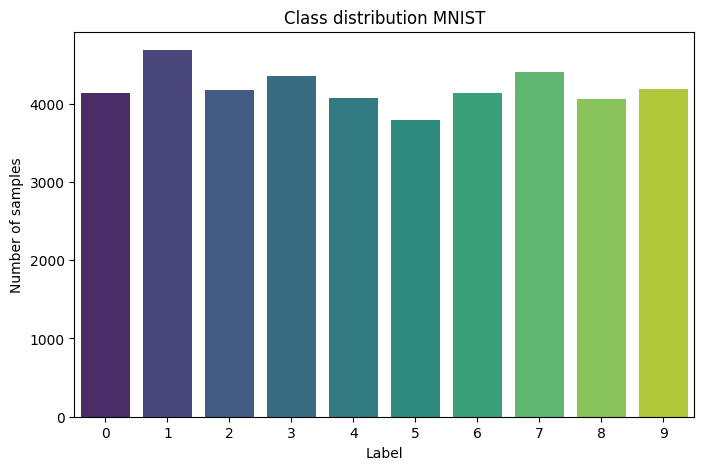

In [15]:
# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Class distribution MNIST')
plt.xlabel('Label')
plt.ylabel('Number of samples')
plt.show()

As we can see data distributed quite evenly (around 4k entries for every digit)

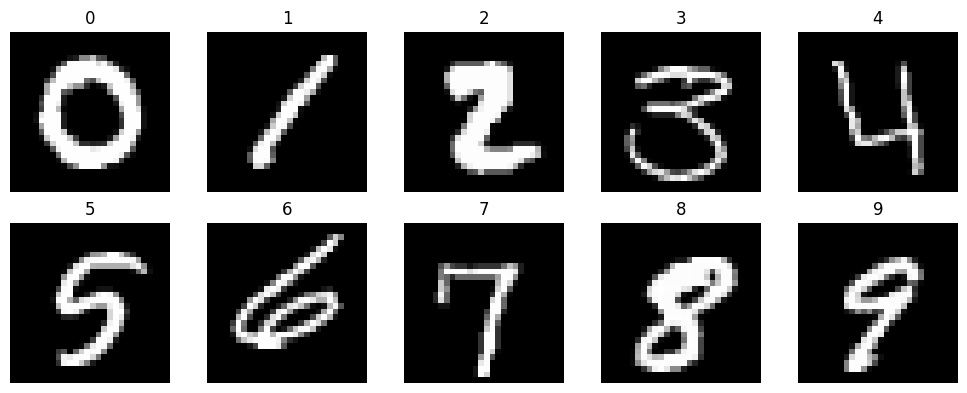

In [16]:
# Plot some samples
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = df[df['label'] == i].iloc[0, 1:].values.reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(str(i))
    plt.axis('off')
plt.tight_layout()
plt.show()

The MNIST dataset contains images of handwritten digits, expanded into flat vectors of 784 pixels (28x28) and a target column label (0 to 9). Checking the class distribution showed that the class is balanced: each digit is represented by approximately the same number of samples, which avoids model bias. The pixel values range from 0 to 255. Since SVM is based on the total distances between points in a multidimensional space, strong differences in pixel intensity require mandatory standardization (normalization) of the label. No data problems (misses or critical anomalies) were detected during the analysis.

Let's check if test dataset is similar to training.

In [22]:
df_test = pd.read_csv('digit-recognizer/test.csv')

df_test.columns

Index(['pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='object', length=784)

As we see label not in the the test dataset so for metric evaluation we will use a sample from training dataset.

### Model training

In [33]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Subset for faster SVM training (SVM is O(N^3) in worst case)
# Returned to full dataset after all, but will use samples in grid and random searches
df_sample = df.sample(n=42000, random_state=42)
X = df_sample.drop('label', axis=1).values
y = df_sample['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

For evaluation we will use accuracy (as dataset is balanced) and also print classification report where we can see other metrics for every represented class.

In [34]:
%%time

# Linear SVM

svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)
acc_linear = accuracy_score(y_test, y_pred_linear)
print(f"Linear Accuracy: {acc_linear:.4f}")
print("Classification report:\n", classification_report(y_test, y_pred_linear))

Linear Accuracy: 0.9168
Classification report:
               precision    recall  f1-score   support

           0       0.96      0.97      0.96       889
           1       0.94      0.98      0.96       939
           2       0.90      0.90      0.90       845
           3       0.86      0.91      0.88       849
           4       0.91      0.92      0.92       787
           5       0.89      0.87      0.88       736
           6       0.94      0.95      0.95       815
           7       0.93      0.93      0.93       896
           8       0.93      0.83      0.88       849
           9       0.91      0.89      0.90       795

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400

CPU times: user 1min 47s, sys: 717 ms, total: 1min 48s
Wall time: 1min 50s


In [35]:
%%time

# Gaussian SVM

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)
acc_rbf = accuracy_score(y_test, y_pred_rbf)
print(f"RBF Accuracy: {acc_rbf:.4f}")
print("Classification report:\n", classification_report(y_test, y_pred_rbf))

RBF Accuracy: 0.9577
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       889
           1       0.98      0.98      0.98       939
           2       0.91      0.96      0.93       845
           3       0.95      0.95      0.95       849
           4       0.96      0.95      0.96       787
           5       0.97      0.95      0.96       736
           6       0.97      0.97      0.97       815
           7       0.96      0.96      0.96       896
           8       0.97      0.93      0.95       849
           9       0.95      0.93      0.94       795

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400

CPU times: user 3min 10s, sys: 589 ms, total: 3min 10s
Wall time: 3min 12s


Here it is important to note that results didn't significantly improve when the training sample was changed from 16k to 33.6k, but there was a big improvent when size changed from 8k to 16k. That proves that dependency on the number of data for SVM is not linear and when we will add even more data we can face performance decrease (especially model fitting will much more time consuming).

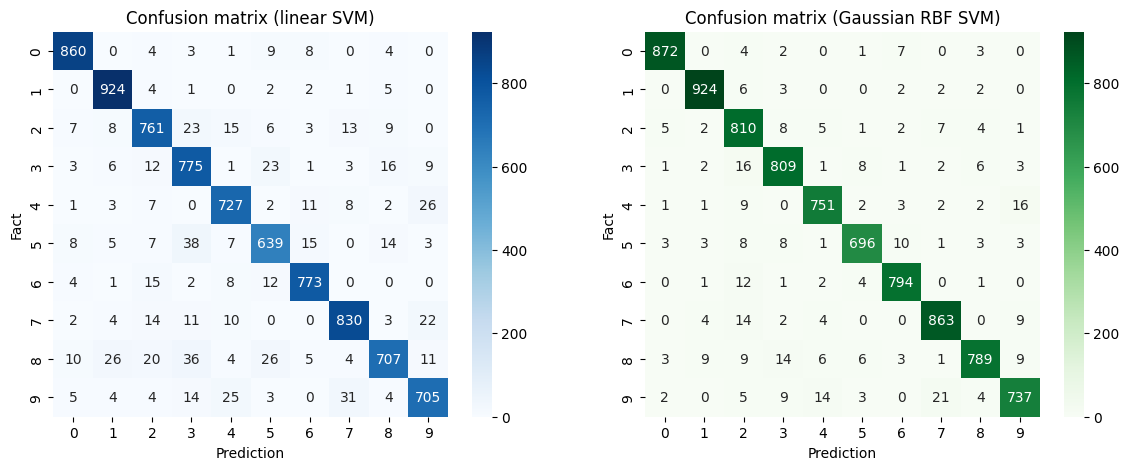

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_linear), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion matrix (linear SVM)')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Fact')

sns.heatmap(confusion_matrix(y_test, y_pred_rbf), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion matrix (Gaussian RBF SVM)')
axes[1].set_xlabel('Prediction')
axes[1].set_ylabel('Fact')
plt.show()

The classification report demonstrates excellent model performance, achieving an overall accuracy of 94% on a well-balanced dataset. The high precision, recall, and F1-scores consistently ranging between 0.93 and 0.98 for RBF and between 0.88 and 0.96 for Linear kernel across all ten digit classes—indicate that the model reliably recognizes each specific number without showing significant bias towards any particular class. This evenly distributed metric profile confirms the model's strong generalization capability and its high effectiveness in solving this multiclass classification task.
This graphics also proves that RBG performs better than Linear kernel for datasets with high number of features.

In [48]:
# Sample of 5k
X_train_sub, _, y_train_sub, _ = train_test_split(X_train_scaled, y_train, train_size=5000, random_state=42)

param_grid = {'C': [0.1, 1, 10, 100, 1000], 'gamma': ['scale', 0.01, 0.001, 0.0001]}

In [49]:
%%time

# GridSearchCV

gs = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=3, n_jobs=-1)
gs.fit(X_train_sub, y_train_sub)

y_pred_grid = gs.best_estimator_.predict(X_test_scaled)

print(f"GridSearch Best Acc: {gs.best_score_:.4f}")

print(f"Accuracy: {accuracy_score(y_test, y_pred_grid):.4f}")
print("Classification report:\n", classification_report(y_test, y_pred_grid))

GridSearch Best Acc: 0.9288
Accuracy: 0.9377
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       889
           1       0.97      0.98      0.97       939
           2       0.93      0.93      0.93       845
           3       0.91      0.93      0.92       849
           4       0.94      0.94      0.94       787
           5       0.94      0.92      0.93       736
           6       0.97      0.94      0.96       815
           7       0.87      0.96      0.91       896
           8       0.96      0.88      0.92       849
           9       0.94      0.89      0.92       795

    accuracy                           0.94      8400
   macro avg       0.94      0.94      0.94      8400
weighted avg       0.94      0.94      0.94      8400

CPU times: user 13.7 s, sys: 173 ms, total: 13.9 s
Wall time: 5min 23s


In [50]:
gs.best_estimator_

SVC(C=100, gamma=0.001)

In [57]:
%%time

# RandomizedSearchCV

rs = RandomizedSearchCV(SVC(kernel='rbf'), param_distributions=param_grid, n_iter=4, cv=3, random_state=42, n_jobs=-1)
rs.fit(X_train_sub, y_train_sub)

y_pred_random = rs.best_estimator_.predict(X_test_scaled)

print(f"RandomSearch Best Acc: {rs.best_score_:.4f}")

print(f"Accuracy: {accuracy_score(y_test, y_pred_random):.4f}")
print("Classification report:\n", classification_report(y_test, y_pred_random))

RandomSearch Best Acc: 0.9130
Accuracy: 0.9244
Classification report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97       889
           1       0.94      0.99      0.96       939
           2       0.90      0.92      0.91       845
           3       0.89      0.92      0.90       849
           4       0.91      0.93      0.92       787
           5       0.91      0.88      0.89       736
           6       0.96      0.94      0.95       815
           7       0.92      0.94      0.93       896
           8       0.94      0.85      0.89       849
           9       0.93      0.89      0.91       795

    accuracy                           0.92      8400
   macro avg       0.92      0.92      0.92      8400
weighted avg       0.92      0.92      0.92      8400

CPU times: user 10.6 s, sys: 54.1 ms, total: 10.6 s
Wall time: 1min 32s


In [58]:
rs.best_estimator_

SVC(C=100, gamma=0.0001)

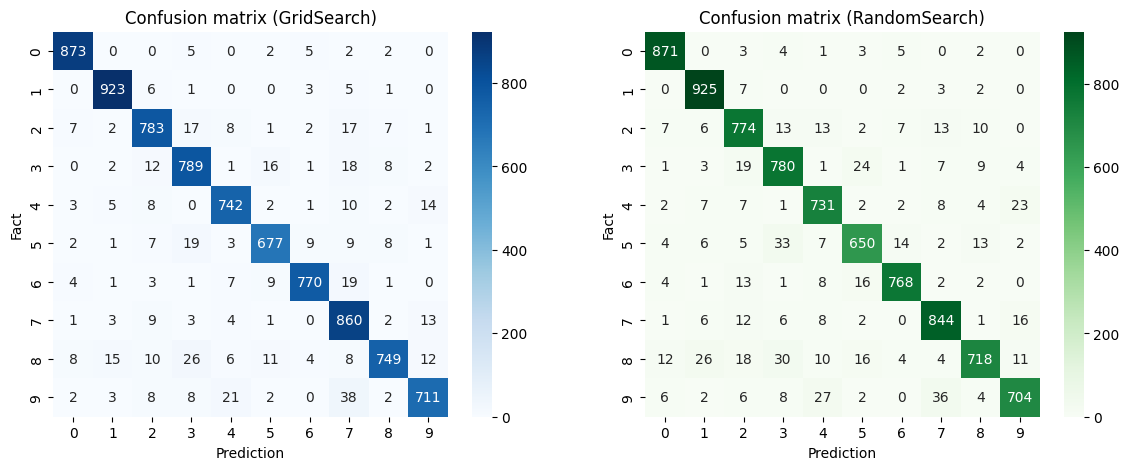

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_grid), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion matrix (GridSearch)')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Fact')

sns.heatmap(confusion_matrix(y_test, y_pred_random), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion matrix (RandomSearch)')
axes[1].set_xlabel('Prediction')
axes[1].set_ylabel('Fact')
plt.show()

Based on the provided results, RandomizedSearchCV proves to be a better method in terms of balancing efficiency, time consumption, and predictive performance.

While GridSearchCV achieved a slightly higher accuracy on the test set (93.77% compared to 92.44%), it required significantly more time to run, taking 5 minutes and 23 seconds. In contrast, RandomizedSearchCV delivered a highly comparable and competitive result while completing the task in just 1 minute and 32 seconds.

Because Randomized Search was approximately 3.5 times faster than Grid Search while only sacrificing about 1.3% in accuracy, it is the superior approach. It demonstrates that we can achieve a good enough high-performing model while drastically reducing computational costs and saving valuable time.

BUT the best method was just a base model with RBF kernel. The reason for it is the data volume. But as we have parameters now let's apply them to a model with more data and check if this will help us to achieve the best model.

In [60]:
%%time

# Gaussian SVM

svm_rbf_1 = SVC(kernel='rbf', C=100.0, gamma=0.001, random_state=42)
svm_rbf_1.fit(X_train_scaled, y_train)

y_pred_rbf_1 = svm_rbf_1.predict(X_test_scaled)
acc_rbf_1 = accuracy_score(y_test, y_pred_rbf_1)
print(f"RBF Accuracy (C=100, gamma=0.001): {acc_rbf_1:.4f}")
print("Classification report:\n", classification_report(y_test, y_pred_rbf_1))

RBF Accuracy (C=100, gamma=0.001): 0.9646
Classification report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       889
           1       0.98      0.99      0.98       939
           2       0.95      0.97      0.96       845
           3       0.95      0.96      0.96       849
           4       0.96      0.95      0.96       787
           5       0.97      0.95      0.96       736
           6       0.97      0.98      0.98       815
           7       0.95      0.98      0.96       896
           8       0.97      0.93      0.95       849
           9       0.96      0.95      0.95       795

    accuracy                           0.96      8400
   macro avg       0.96      0.96      0.96      8400
weighted avg       0.96      0.96      0.96      8400

CPU times: user 2min 31s, sys: 722 ms, total: 2min 31s
Wall time: 2min 33s


In [64]:
%%time

# Gaussian SVM

svm_rbf_2 = SVC(kernel='rbf', C=100.0, gamma=0.0001, random_state=42)
svm_rbf_2.fit(X_train_scaled, y_train)

y_pred_rbf_2 = svm_rbf_2.predict(X_test_scaled)
acc_rbf_2 = accuracy_score(y_test, y_pred_rbf_2)
print(f"RBF Accuracy (C=100, gamma=0.0001): {acc_rbf_2:.4f}")
print("Classification report:\n", classification_report(y_test, y_pred_rbf_2))

RBF Accuracy (C=100, gamma=0.0001): 0.9514
Classification report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       889
           1       0.96      0.99      0.97       939
           2       0.94      0.95      0.94       845
           3       0.92      0.95      0.93       849
           4       0.94      0.95      0.94       787
           5       0.95      0.93      0.94       736
           6       0.96      0.98      0.97       815
           7       0.96      0.96      0.96       896
           8       0.96      0.90      0.93       849
           9       0.94      0.93      0.94       795

    accuracy                           0.95      8400
   macro avg       0.95      0.95      0.95      8400
weighted avg       0.95      0.95      0.95      8400

CPU times: user 1min 39s, sys: 357 ms, total: 1min 39s
Wall time: 1min 40s


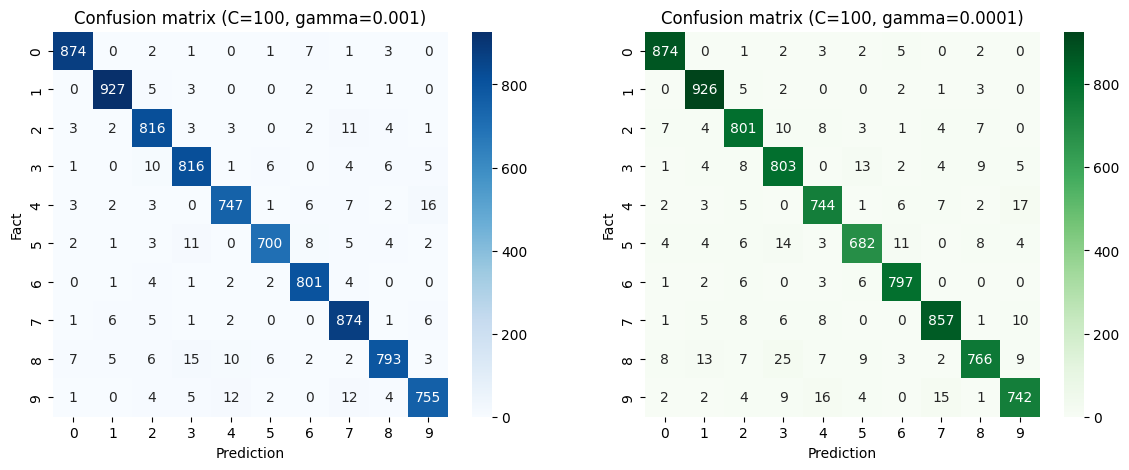

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_rbf_1), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion matrix (C=100, gamma=0.001)')
axes[0].set_xlabel('Prediction')
axes[0].set_ylabel('Fact')

sns.heatmap(confusion_matrix(y_test, y_pred_rbf_2), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion matrix (C=100, gamma=0.0001)')
axes[1].set_xlabel('Prediction')
axes[1].set_ylabel('Fact')
plt.show()

As we see the combination of approaches worked, and on the bigger amount of data SVC(kernel='rbf', C=100.0, gamma=0.001, random_state=42) is the best SVM for this classification task.